In [2]:
print("Alpha Factory Ready")
!pip install yfinance pandas numpy scikit-learn scipy plotly -q
import sys

!{sys.executable} -m pip install yfinance pandas numpy scikit-learn scipy plotly matplotlib
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go

from scipy import stats
from sklearn.ensemble import RandomForestRegressor

print("Imports successful")

Alpha Factory Ready
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------  9.2/9.3 MB 91.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 29.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 25.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 39.7 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pypa

In [2]:
tickers = ["AAPL", "MSFT", "NVDA"]

prices = yf.download(
    tickers,
    start="2020-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices.tail()

Ticker,AAPL,MSFT,NVDA
Date,,,
2026-06-16,299.239990,393.829987,207.410004
2026-06-17,295.950012,378.910004,204.649994
2026-06-18,298.010010,379.399994,210.690002
2026-06-22,297.010010,367.339996,208.649994
2026-06-23,294.299988,373.940002,200.039993


In [3]:
fig = go.Figure()

for stock in prices.columns:
    fig.add_trace(
        go.Scatter(
            x=prices.index,
            y=prices[stock],
            name=stock
        )
    )

fig.update_layout(
    title="AAPL vs MSFT vs NVDA",
    xaxis_title="Date",
    yaxis_title="Price ($)",
    template="plotly_white",
    height=600
)

fig.show()

In [4]:
import sys

!{sys.executable} -m pip install nbformat ipykernel jupyter

In [5]:
# ============================================================
# CELL 1: Define Institutional Equity Universe
# ============================================================

TICKERS = [
    "AAPL","MSFT","NVDA","GOOGL","AMZN",
    "META","JPM","V","MA","UNH",
    "HD","PG","XOM","CVX","LLY",
    "AVGO","COST","PEP","KO","MRK",
    "WMT","BAC","ADBE","NFLX","CRM",
    "AMD","INTC","TMO","ABT","MCD",

    "TSLA","ORCL","QCOM","TXN","AMAT",
    "BKNG","UBER","PANW","PLTR","SNOW",
    "GS","MS","SCHW","BLK","C",
    "LOW","TGT","NKE","SBUX","CMG",
    "COP","SLB","EOG","MPC","PSX",
    "DHR","ISRG","VRTX","REGN","MDT",
    "LMT","RTX","BA","NOC","GD",
    "SPGI","ICE","MCO","ADP","PAYX",
    "DE","ETN","PH","EMR","ROK"
]

BENCHMARK = "SPY"
START_DATE = "2016-01-01"

all_tickers = TICKERS + [BENCHMARK]

print(f"Universe size: {len(TICKERS)} stocks")

Universe size: 75 stocks


In [6]:
# ============================================================
# CELL 2: Download Market Data
# ============================================================

data = yf.download(
    all_tickers,
    start=START_DATE,
    auto_adjust=True,
    progress=False
)

prices = data["Close"].ffill().dropna()

stock_prices = prices[TICKERS]
benchmark_prices = prices[BENCHMARK]

prices.tail()

Ticker,AAPL,ABT,ADBE,ADP,AMAT,AMD,AMZN,AVGO,BA,BAC,...,TGT,TMO,TSLA,TXN,UBER,UNH,V,VRTX,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-16,299.239990,90.620003,207.320007,222.000000,568.229980,507.290009,246.000000,376.114716,227.490005,56.840000,...,133.399994,472.630005,404.660004,305.709991,73.250000,407.649994,333.119995,453.170013,121.029999,141.860001
2026-06-17,295.950012,88.500000,196.279999,218.759995,592.919983,512.479980,237.500000,392.279144,225.630005,56.529999,...,127.809998,461.690002,396.380005,301.880005,70.910004,399.529999,330.380005,458.989990,118.129997,140.740005
2026-06-18,298.010010,88.410004,195.160004,218.410004,617.109985,537.369995,244.389999,410.700012,222.720001,56.200001,...,130.740005,464.609985,400.489990,322.859985,71.639999,400.959991,327.239990,451.630005,117.180000,137.809998
2026-06-22,297.010010,87.830002,194.899994,214.600006,640.179993,551.630005,232.789993,392.130005,220.830002,57.369999,...,129.729996,464.010010,405.049988,332.279999,71.430000,406.679993,326.600006,466.790009,117.180000,138.470001
2026-06-23,294.299988,90.529999,197.429993,220.500000,585.880005,519.849976,234.110001,380.149994,216.710007,57.910000,...,134.110001,469.350006,381.609985,304.359985,69.669998,409.250000,328.480011,468.420013,119.419998,139.729996


In [7]:
# ============================================================
# CELL 3: Calculate Daily Returns
# ============================================================

returns = prices.pct_change().dropna()

stock_returns = returns[TICKERS]
benchmark_returns = returns[BENCHMARK]

stock_returns.tail()

Ticker,AAPL,MSFT,NVDA,GOOGL,AMZN,META,JPM,V,MA,UNH,...,SPGI,ICE,MCO,ADP,PAYX,DE,ETN,PH,EMR,ROK
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-16,0.009513,-0.014834,-0.023723,0.010559,-0.000081,0.011340,0.036756,0.028720,0.021788,-0.008247,...,0.021647,0.008423,0.031604,-0.005465,-0.006145,0.017064,0.001597,0.021385,0.015629,0.005911
2026-06-17,-0.010994,-0.037884,-0.013307,-0.025345,-0.034553,-0.054364,0.007006,-0.008225,-0.016636,-0.019919,...,-0.035153,-0.047353,-0.026024,-0.014595,-0.026925,0.005433,0.004734,0.007949,0.001277,-0.016341
2026-06-18,0.006961,0.001293,0.029514,0.011655,0.029011,0.016984,-0.024711,-0.009504,-0.006491,0.003579,...,-0.016985,-0.005275,-0.012165,-0.001600,0.006764,0.001309,0.029611,0.007717,0.011141,0.032920
2026-06-22,-0.003356,-0.031787,-0.009683,-0.049860,-0.047465,-0.023163,0.019249,-0.001956,-0.011638,0.014266,...,-0.008590,-0.018972,-0.007411,-0.017444,-0.023514,0.015868,0.033217,0.009305,-0.002987,0.009055
2026-06-23,-0.009124,0.017967,-0.041265,-0.010152,0.005670,-0.002926,0.008025,0.005756,0.008222,0.006319,...,-0.017747,0.012639,-0.007511,0.027493,0.021474,-0.011109,-0.069989,-0.015133,-0.047067,-0.045432


In [8]:
# ============================================================
# CELL 4: Feature Engineering
# ============================================================

feature_frames = []

for ticker in TICKERS:
    px = stock_prices[ticker]
    ret = stock_returns[ticker]

    df = pd.DataFrame(index=stock_prices.index)
    df["ticker"] = ticker

    df["mom_5"] = px.pct_change(5)
    df["mom_20"] = px.pct_change(20)
    df["mom_60"] = px.pct_change(60)
    df["reversal_5"] = -df["mom_5"]

    df["vol_20"] = ret.rolling(20).std()
    df["vol_60"] = ret.rolling(60).std()

    df["ma_dist_20"] = px / px.rolling(20).mean() - 1
    df["rel_strength_20"] = px.pct_change(20) - benchmark_prices.pct_change(20)

    df["future_return_5d"] = px.pct_change(5).shift(-5)

    feature_frames.append(df)

features = pd.concat(feature_frames).dropna()

features.head()

,ticker,mom_5,mom_20,mom_60,reversal_5,vol_20,vol_60,ma_dist_20,rel_strength_20,future_return_5d
Date,,,,,,,,,,
2020-12-24,AAPL,0.025408,0.137378,0.141505,-0.025408,0.016706,0.021803,0.056580,0.115559,-0.019398
2020-12-28,AAPL,0.079188,0.172399,0.172411,-0.079188,0.017922,0.022211,0.085634,0.144664,-0.041554
2020-12-29,AAPL,0.051782,0.132886,0.195388,-0.051782,0.018261,0.021834,0.064492,0.102550,-0.061318
2020-12-30,AAPL,0.013952,0.089635,0.149792,-0.013952,0.017600,0.021581,0.050853,0.068993,-0.020940
2020-12-31,AAPL,0.013210,0.078079,0.174611,-0.013210,0.017807,0.021234,0.038836,0.054404,-0.004824


In [9]:
# ============================================================
# CELL 5: Cross-Sectional Normalization
# ============================================================

feature_cols = [
    "mom_5", "mom_20", "mom_60",
    "reversal_5",
    "vol_20", "vol_60",
    "ma_dist_20",
    "rel_strength_20"
]

for col in feature_cols:
    features[col + "_z"] = features.groupby(features.index)[col].transform(
        lambda x: stats.zscore(x, nan_policy="omit")
    )

features = features.replace([np.inf, -np.inf], np.nan).dropna()

features.head()

,ticker,mom_5,mom_20,mom_60,reversal_5,vol_20,vol_60,ma_dist_20,rel_strength_20,future_return_5d,mom_5_z,mom_20_z,mom_60_z,reversal_5_z,vol_20_z,vol_60_z,ma_dist_20_z,rel_strength_20_z
Date,,,,,,,,,,,,,,,,,,
2020-12-24,AAPL,0.025408,0.137378,0.141505,-0.025408,0.016706,0.021803,0.056580,0.115559,-0.019398,1.034694,1.959467,-0.125703,-1.034694,-0.020089,-0.068479,1.587400,1.959467
2020-12-28,AAPL,0.079188,0.172399,0.172411,-0.079188,0.017922,0.022211,0.085634,0.144664,-0.041554,2.811298,2.618789,-0.000802,-2.811298,0.083448,-0.025211,2.369544,2.618789
2020-12-29,AAPL,0.051782,0.132886,0.195388,-0.051782,0.018261,0.021834,0.064492,0.102550,-0.061318,1.724648,1.756358,0.072791,-1.724648,0.187495,-0.048283,1.938122,1.756358
2020-12-30,AAPL,0.013952,0.089635,0.149792,-0.013952,0.017600,0.021581,0.050853,0.068993,-0.020940,0.188279,1.139217,-0.053629,-0.188279,0.143742,-0.057980,1.493249,1.139217
2020-12-31,AAPL,0.013210,0.078079,0.174611,-0.013210,0.017807,0.021234,0.038836,0.054404,-0.004824,0.079707,0.901560,-0.014268,-0.079707,0.212318,-0.083042,0.790941,0.901560


In [10]:
# ============================================================
# CELL 6: Build Composite Alpha Score
# ============================================================

features["alpha_score"] = (
    0.25 * features["mom_20_z"] +
    0.20 * features["mom_60_z"] +
    0.15 * features["reversal_5_z"] -
    0.20 * features["vol_20_z"] +
    0.20 * features["rel_strength_20_z"]
)

features[["ticker", "alpha_score", "future_return_5d"]].head()

,ticker,alpha_score,future_return_5d
Date,,,
2020-12-24,AAPL,0.705433,-0.019398
2020-12-28,AAPL,0.739911,-0.041554
2020-12-29,AAPL,0.508723,-0.061318
2020-12-30,AAPL,0.444932,-0.020940
2020-12-31,AAPL,0.348429,-0.004824


In [11]:
# ============================================================
# CELL 7: Train Machine Learning Alpha Model
# ============================================================

model_features = [col + "_z" for col in feature_cols] + ["alpha_score"]

dates = sorted(features.index.unique())
split = int(len(dates) * 0.75)

train_dates = dates[:split]
test_dates = dates[split:]

train = features[features.index.isin(train_dates)]
test = features[features.index.isin(test_dates)].copy()

X_train = train[model_features]
y_train = train["future_return_5d"]

X_test = test[model_features]
y_test = test["future_return_5d"]

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

test["prediction"] = model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [12]:
# ============================================================
# CELL 8: Long/Short Portfolio Construction
# ============================================================

portfolio_frames = []

for date, group in test.groupby(test.index):
    group = group.copy()

    long_cutoff = group["prediction"].quantile(0.80)
    short_cutoff = group["prediction"].quantile(0.20)

    group["position"] = 0
    group.loc[group["prediction"] >= long_cutoff, "position"] = 1
    group.loc[group["prediction"] <= short_cutoff, "position"] = -1

    longs = (group["position"] == 1).sum()
    shorts = (group["position"] == -1).sum()

    group["weight"] = 0.0

    if longs > 0:
        group.loc[group["position"] == 1, "weight"] = 0.5 / longs

    if shorts > 0:
        group.loc[group["position"] == -1, "weight"] = -0.5 / shorts

    portfolio_frames.append(group)

portfolio = pd.concat(portfolio_frames)

portfolio[["ticker", "prediction", "position", "weight"]].head()

,ticker,prediction,position,weight
Date,,,,
2025-01-31,AAPL,0.004945,0,0.0
2025-01-31,MSFT,0.004431,0,0.0
2025-01-31,NVDA,0.004440,0,0.0
2025-01-31,GOOGL,0.004654,0,0.0
2025-01-31,AMZN,0.003058,0,0.0


In [13]:
# ============================================================
# CELL 9: Backtest Engine
# ============================================================

daily_results = []

for date, group in portfolio.groupby(portfolio.index):
    strategy_return = (group["weight"] * group["future_return_5d"]).sum() / 5

    daily_results.append({
        "date": date,
        "strategy_return": strategy_return
    })

backtest = pd.DataFrame(daily_results).set_index("date")
backtest["equity_curve"] = (1 + backtest["strategy_return"]).cumprod()

backtest.tail()

,strategy_return,equity_curve
date,,
2026-06-09,0.000432,1.236361
2026-06-10,0.001045,1.237653
2026-06-11,0.004046,1.242660
2026-06-12,0.002694,1.246008
2026-06-15,-0.001126,1.244605


In [14]:
# ============================================================
# CELL 10: Performance Metrics
# ============================================================

r = backtest["strategy_return"]

cumulative_return = (1 + r).prod() - 1
cagr = (1 + cumulative_return) ** (252 / len(r)) - 1
volatility = r.std() * np.sqrt(252)
sharpe = r.mean() / r.std() * np.sqrt(252)

equity = backtest["equity_curve"]
drawdown = equity / equity.cummax() - 1
max_drawdown = drawdown.min()

metrics = pd.Series({
    "Cumulative Return": cumulative_return,
    "CAGR": cagr,
    "Annualized Volatility": volatility,
    "Sharpe Ratio": sharpe,
    "Max Drawdown": max_drawdown
})

metrics

Cumulative Return        0.244605
CAGR                     0.173859
Annualized Volatility    0.041214
Sharpe Ratio             3.911107
Max Drawdown            -0.031927
dtype: float64

In [15]:
# ============================================================
# CELL 11: Equity Curve Visualization
# ============================================================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=backtest.index,
    y=backtest["equity_curve"],
    mode="lines",
    name="Alpha Factory Strategy"
))

fig.update_layout(
    title="Institutional Alpha Factory: Equity Curve",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    template="plotly_white",
    height=600
)

fig.show()

In [16]:
# ============================================================
# CELL 12: Drawdown Visualization
# ============================================================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=drawdown.index,
    y=drawdown,
    mode="lines",
    name="Drawdown"
))

fig.update_layout(
    title="Strategy Drawdown",
    xaxis_title="Date",
    yaxis_title="Drawdown",
    template="plotly_white",
    height=500
)

fig.show()

In [17]:
# ============================================================
# CELL 13: Feature Importance
# ============================================================

importance = pd.DataFrame({
    "feature": model_features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=importance["importance"],
    y=importance["feature"],
    orientation="h"
))

fig.update_layout(
    title="Machine Learning Feature Importance",
    xaxis_title="Importance",
    yaxis_title="Feature",
    template="plotly_white",
    height=500
)

fig.show()

importance

,feature,importance
4,vol_20_z,0.277132
2,mom_60_z,0.225085
5,vol_60_z,0.199708
6,ma_dist_20_z,0.098713
8,alpha_score,0.061825
0,mom_5_z,0.040251
1,mom_20_z,0.035730
3,reversal_5_z,0.034563
7,rel_strength_20_z,0.026994


In [18]:
# ============================================================
# CELL 14: Export Results
# ============================================================

backtest.to_csv("alpha_factory_backtest.csv")
portfolio.to_csv("alpha_factory_portfolio_weights.csv")
metrics.to_csv("alpha_factory_metrics.csv")
importance.to_csv("alpha_factory_feature_importance.csv", index=False)

print("Files exported successfully")

Files exported successfully


In [19]:
# ============================================================
# CELL 15: Information Coefficient
# ============================================================

daily_ic = []

for date, group in portfolio.groupby(portfolio.index):
    ic = group["prediction"].corr(
        group["future_return_5d"],
        method="spearman"
    )

    daily_ic.append({
        "date": date,
        "information_coefficient": ic
    })

ic_df = pd.DataFrame(daily_ic).set_index("date")

average_ic = ic_df["information_coefficient"].mean()
ic_ir = average_ic / ic_df["information_coefficient"].std()

print("Average IC:", round(average_ic, 4))
print("ICIR:", round(ic_ir, 4))

ic_df.tail()

Average IC: 0.038
ICIR: 0.1876


,information_coefficient
date,
2026-06-09,-0.062219
2026-06-10,-0.070100
2026-06-11,0.165661
2026-06-12,0.170640
2026-06-15,-0.184609


In [20]:
# ============================================================
# CELL 16: Rolling Sharpe Ratio
# ============================================================

rolling_sharpe = (
    backtest["strategy_return"].rolling(63).mean()
    / backtest["strategy_return"].rolling(63).std()
) * np.sqrt(252)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=rolling_sharpe.index,
    y=rolling_sharpe,
    mode="lines",
    name="63-Day Rolling Sharpe"
))

fig.update_layout(
    title="Rolling Sharpe Ratio",
    xaxis_title="Date",
    yaxis_title="Sharpe Ratio",
    template="plotly_white",
    height=500
)

fig.show()

In [21]:
# ============================================================
# CELL 17: Strategy vs Benchmark
# ============================================================

benchmark_aligned = benchmark_returns.reindex(backtest.index).fillna(0)
benchmark_curve = (1 + benchmark_aligned).cumprod()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=backtest.index,
    y=backtest["equity_curve"],
    mode="lines",
    name="Alpha Factory Strategy"
))

fig.add_trace(go.Scatter(
    x=benchmark_curve.index,
    y=benchmark_curve,
    mode="lines",
    name="SPY Benchmark"
))

fig.update_layout(
    title="Strategy vs SPY Benchmark",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    template="plotly_white",
    height=600
)

fig.show()

In [22]:
# ============================================================
# CELL 18: Final Project Summary
# ============================================================

print("=" * 70)
print("INSTITUTIONAL ALPHA FACTORY - FINAL SUMMARY")
print("=" * 70)

print("\nUniverse Size:")
print(len(TICKERS))

print("\nBacktest Period:")
print(backtest.index.min(), "to", backtest.index.max())

print("\nPerformance Metrics:")
display(metrics)

print("\nSignal Quality:")
print("Average IC:", round(average_ic, 4))
print("ICIR:", round(ic_ir, 4))

print("\nTop Feature Importances:")
display(importance.head(10))

print("\nLatest Portfolio Positions:")
latest_date = portfolio.index.max()

display(
    portfolio.loc[latest_date, ["ticker", "prediction", "position", "weight"]]
    .sort_values("weight", ascending=False)
)

INSTITUTIONAL ALPHA FACTORY - FINAL SUMMARY

Universe Size:
75

Backtest Period:
2025-01-31 00:00:00 to 2026-06-15 00:00:00

Performance Metrics:


Cumulative Return        0.244605
CAGR                     0.173859
Annualized Volatility    0.041214
Sharpe Ratio             3.911107
Max Drawdown            -0.031927
dtype: float64


Signal Quality:
Average IC: 0.038
ICIR: 0.1876

Top Feature Importances:


,feature,importance
4,vol_20_z,0.277132
2,mom_60_z,0.225085
5,vol_60_z,0.199708
6,ma_dist_20_z,0.098713
8,alpha_score,0.061825
0,mom_5_z,0.040251
1,mom_20_z,0.035730
3,reversal_5_z,0.034563
7,rel_strength_20_z,0.026994



Latest Portfolio Positions:


,ticker,prediction,position,weight
Date,,,,
2026-06-15,NVDA,0.005187,1,0.033333
2026-06-15,META,0.005157,1,0.033333
2026-06-15,BA,0.005125,1,0.033333
2026-06-15,TXN,0.005270,1,0.033333
2026-06-15,ORCL,0.005285,1,0.033333
...,...,...,...,...
2026-06-15,COP,0.001975,-1,-0.033333
2026-06-15,DHR,0.001649,-1,-0.033333
2026-06-15,PSX,0.000825,-1,-0.033333


In [23]:
# ============================================================
# CELL 19: 52-Week High Alpha Signal
# ============================================================

high_252 = stock_prices.rolling(252).max()

distance_to_52w_high = stock_prices / high_252 - 1

latest_52w_signal = distance_to_52w_high.iloc[-1].sort_values(ascending=False)

latest_52w_signal

Ticker
JPM     0.000000
BAC     0.000000
UNH    -0.004355
MS     -0.004668
C      -0.004805
          ...   
NKE    -0.450493
NFLX   -0.456214
CMG    -0.468578
ORCL   -0.493000
ADBE   -0.496481
Name: 2026-06-23 00:00:00, Length: 75, dtype: float64

In [24]:
# ============================================================
# CELL 20: Add 52-Week High Signal to Feature Panel
# ============================================================

signal_frames = []

for ticker in TICKERS:
    df = pd.DataFrame(index=stock_prices.index)
    df["ticker"] = ticker
    df["high_252_signal"] = stock_prices[ticker] / stock_prices[ticker].rolling(252).max() - 1

    signal_frames.append(df)

high_signal_panel = pd.concat(signal_frames).dropna()

features_enhanced = features.merge(
    high_signal_panel,
    left_index=True,
    right_index=True,
    how="inner",
    suffixes=("", "_drop")
)

features_enhanced = features_enhanced.loc[:, ~features_enhanced.columns.str.endswith("_drop")]

features_enhanced.head()

,ticker,mom_5,mom_20,mom_60,reversal_5,vol_20,vol_60,ma_dist_20,rel_strength_20,future_return_5d,mom_5_z,mom_20_z,mom_60_z,reversal_5_z,vol_20_z,vol_60_z,ma_dist_20_z,rel_strength_20_z,alpha_score,high_252_signal
Date,,,,,,,,,,,,,,,,,,,,
2021-09-29,AAPL,-0.020706,-0.059277,0.007211,0.020706,0.013381,0.013003,-0.03913,-0.024468,-0.005811,-0.456313,-0.621808,-0.193028,0.456313,-0.194731,-0.289934,-0.660981,-0.621808,-0.211026,-0.088455
2021-09-29,AAPL,-0.020706,-0.059277,0.007211,0.020706,0.013381,0.013003,-0.03913,-0.024468,-0.005811,-0.456313,-0.621808,-0.193028,0.456313,-0.194731,-0.289934,-0.660981,-0.621808,-0.211026,-0.069523
2021-09-29,AAPL,-0.020706,-0.059277,0.007211,0.020706,0.013381,0.013003,-0.03913,-0.024468,-0.005811,-0.456313,-0.621808,-0.193028,0.456313,-0.194731,-0.289934,-0.660981,-0.621808,-0.211026,-0.101826
2021-09-29,AAPL,-0.020706,-0.059277,0.007211,0.020706,0.013381,0.013003,-0.03913,-0.024468,-0.005811,-0.456313,-0.621808,-0.193028,0.456313,-0.194731,-0.289934,-0.660981,-0.621808,-0.211026,-0.074799
2021-09-29,AAPL,-0.020706,-0.059277,0.007211,0.020706,0.013381,0.013003,-0.03913,-0.024468,-0.005811,-0.456313,-0.621808,-0.193028,0.456313,-0.194731,-0.289934,-0.660981,-0.621808,-0.211026,-0.115316


In [25]:
# ============================================================
# CELL 21: Normalize New Alpha Signal
# ============================================================

features_enhanced["high_252_signal_z"] = (
    features_enhanced
    .groupby(features_enhanced.index)["high_252_signal"]
    .transform(lambda x: stats.zscore(x, nan_policy="omit"))
)

features_enhanced = features_enhanced.replace([np.inf, -np.inf], np.nan).dropna()

features_enhanced[["ticker", "high_252_signal", "high_252_signal_z"]].head()

,ticker,high_252_signal,high_252_signal_z
Date,,,
2021-09-29,AAPL,-0.088455,0.011793
2021-09-29,AAPL,-0.069523,0.270816
2021-09-29,AAPL,-0.101826,-0.171155
2021-09-29,AAPL,-0.074799,0.198631
2021-09-29,AAPL,-0.115316,-0.355726


In [26]:
# ============================================================
# CELL 22: Enhanced Alpha Score with 52-Week High Factor
# ============================================================

features_enhanced["enhanced_alpha_score"] = (
    0.20 * features_enhanced["mom_20_z"] +
    0.20 * features_enhanced["mom_60_z"] +
    0.15 * features_enhanced["reversal_5_z"] -
    0.15 * features_enhanced["vol_20_z"] +
    0.15 * features_enhanced["rel_strength_20_z"] +
    0.15 * features_enhanced["high_252_signal_z"]
)

features_enhanced[[
    "ticker",
    "alpha_score",
    "enhanced_alpha_score",
    "future_return_5d"
]].head()

,ticker,alpha_score,enhanced_alpha_score,future_return_5d
Date,,,,
2021-09-29,AAPL,-0.211026,-0.156813,-0.005811
2021-09-29,AAPL,-0.211026,-0.117959,-0.005811
2021-09-29,AAPL,-0.211026,-0.184255,-0.005811
2021-09-29,AAPL,-0.211026,-0.128787,-0.005811
2021-09-29,AAPL,-0.211026,-0.211941,-0.005811


In [27]:
from sklearn.metrics import mean_squared_error

In [28]:
# ============================================================
# CELL 23: Train Enhanced Alpha Model
# ============================================================

enhanced_model_features = model_features + ["high_252_signal_z", "enhanced_alpha_score"]

dates = sorted(features_enhanced.index.unique())
split = int(len(dates) * 0.75)

train_dates = dates[:split]
test_dates = dates[split:]

enhanced_train = features_enhanced[features_enhanced.index.isin(train_dates)]
enhanced_test = features_enhanced[features_enhanced.index.isin(test_dates)].copy()

X_train = enhanced_train[enhanced_model_features]
y_train = enhanced_train["future_return_5d"]

X_test = enhanced_test[enhanced_model_features]
y_test = enhanced_test["future_return_5d"]

enhanced_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

enhanced_model.fit(X_train, y_train)

enhanced_test["enhanced_prediction"] = enhanced_model.predict(X_test)

enhanced_rmse = np.sqrt(mean_squared_error(y_test, enhanced_test["enhanced_prediction"]))

print("Enhanced model trained successfully")
print("Enhanced RMSE:", round(enhanced_rmse, 6))

Enhanced model trained successfully
Enhanced RMSE: 0.048217


In [29]:
# ============================================================
# CELL 24: Alpha Ranking Engine
# ============================================================

enhanced_test["alpha_score"] = enhanced_test["enhanced_prediction"]

alpha_ranking = enhanced_test.sort_values(
    "alpha_score",
    ascending=False
)

print("Top Alpha Signals")

display(
    alpha_ranking[
        [
            "ticker",
            "future_return_5d",
            "enhanced_prediction",
            "alpha_score"
        ]
    ].head(20)
)

Top Alpha Signals


,ticker,future_return_5d,enhanced_prediction,alpha_score
Date,,,,
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976
2026-02-04,INTC,-0.006379,0.158976,0.158976


In [30]:
# ============================================================
# CHECK: How many stocks are actually in the ranking?
# ============================================================

print("Number of unique tickers in alpha_ranking:")
print(alpha_ranking["ticker"].nunique())

print("\nTickers included:")
print(alpha_ranking["ticker"].unique())

Number of unique tickers in alpha_ranking:
75

Tickers included:
<StringArray>
[ 'INTC',  'SNOW',   'UNH',  'ORCL',   'AMD',  'TSLA',  'VRTX',  'AVGO',
  'AMAT',   'NKE',   'CRM',  'ADBE',  'NVDA',  'BKNG',   'TXN',   'SLB',
    'BA',  'PLTR',  'META',  'AAPL',   'ETN',   'MPC',    'PH',   'PSX',
   'COP',   'LLY',  'QCOM',   'MCO',    'GS',     'C',  'SBUX',  'PANW',
    'MS',  'AMZN',   'CMG',   'ROK',   'EMR',  'ISRG',  'UBER',   'TGT',
    'DE',  'SPGI',  'NFLX',   'NOC',   'TMO',   'BLK',   'DHR',   'BAC',
   'EOG',  'REGN',   'RTX',   'CVX',   'ADP',   'LOW',  'PAYX',    'MA',
   'JPM',   'MRK',   'MDT',  'MSFT',   'ABT',   'PEP', 'GOOGL',   'MCD',
    'PG',     'V',    'HD',   'LMT',   'ICE',   'XOM',  'SCHW',    'GD',
   'WMT',    'KO',  'COST']
Length: 75, dtype: str


In [31]:
# ============================================================
# CELL 25: Portfolio Construction
# ============================================================

latest_signals = (
    alpha_ranking
    .groupby("ticker")
    .tail(1)
    .sort_values("alpha_score", ascending=False)
)

longs = latest_signals.head(5).copy()
shorts = latest_signals.tail(5).copy()

longs["weight"] = 1 / len(longs)
shorts["weight"] = -1 / len(shorts)

enhanced_portfolio = pd.concat([longs, shorts])

print("LONG BOOK")
display(
    longs[
        [
            "ticker",
            "alpha_score",
            "enhanced_prediction",
            "weight"
        ]
    ]
)

print("SHORT BOOK")
display(
    shorts[
        [
            "ticker",
            "alpha_score",
            "enhanced_prediction",
            "weight"
        ]
    ]
)

LONG BOOK


,ticker,alpha_score,enhanced_prediction,weight
Date,,,,
2026-06-15,AVGO,0.003172,0.003172,0.2
2026-06-15,COP,0.001390,0.001390,0.2
2026-06-04,SLB,0.001390,0.001390,0.2
2025-04-10,CRM,0.001390,0.001390,0.2
2026-06-05,MPC,0.001390,0.001390,0.2


SHORT BOOK


,ticker,alpha_score,enhanced_prediction,weight
Date,,,,
2026-03-06,LMT,-0.036037,-0.036037,-0.2
2025-11-25,LLY,-0.049895,-0.049895,-0.2
2025-12-17,ORCL,-0.107031,-0.107031,-0.2
2026-05-08,INTC,-0.127568,-0.127568,-0.2
2025-05-14,UNH,-0.158849,-0.158849,-0.2


In [32]:
# ============================================================
# CELL 26: Portfolio Performance
# ============================================================

portfolio_return = (
    longs["future_return_5d"].mean()
    - shorts["future_return_5d"].mean()
)

print("="*50)
print("LONG-SHORT PORTFOLIO RETURN")
print("="*50)

print(f"Expected Return: {portfolio_return:.4%}")

LONG-SHORT PORTFOLIO RETURN
Expected Return: 0.6562%


In [ ]:
# ============================================================
# CELL 27: EQUITY CURVE
# ============================================================

backtest = alpha_ranking.copy()

backtest["strategy_return"] = (
    backtest["alpha_score"] *
    backtest["future_return_5d"]
)

backtest["equity_curve"] = (
    1 + backtest["strategy_return"]
).cumprod()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=backtest.index,
        y=backtest["equity_curve"],
        mode="lines",
        name="Alpha Strategy"
    )
)

fig.update_layout(
    title="Institutional Alpha Strategy Equity Curve",
    xaxis_title="Observations",
    yaxis_title="Portfolio Value",
    template="plotly_white",
    height=600
)

fig.show()

In [ ]:
# ============================================================
# CELL 28: Fixed Equity Curve
# ============================================================

alpha_ranking["strategy_return"] = (
    alpha_ranking["alpha_score"]
    * alpha_ranking["future_return_5d"]
)

daily_returns = (
    alpha_ranking
    .groupby(alpha_ranking.index)["strategy_return"]
    .mean()
)

equity_curve = (1 + daily_returns).cumprod()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=equity_curve.index,
        y=equity_curve.values,
        mode="lines",
        name="Alpha Portfolio"
    )
)

fig.update_layout(
    title="Fixed Institutional Alpha Portfolio Equity Curve",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    template="plotly_white",
    height=600
)

fig.show()

In [ ]:
# ============================================================
# CELL 29: Institutional Performance Metrics
# ============================================================

sharpe = (
    daily_returns.mean()
    /
    daily_returns.std()
) * np.sqrt(252)

running_max = equity_curve.cummax()

drawdown = (
    equity_curve
    /
    running_max
    - 1
)

max_drawdown = drawdown.min()

total_return = (
    equity_curve.iloc[-1]
    /
    equity_curve.iloc[0]
    - 1
)

print("="*50)
print("INSTITUTIONAL PERFORMANCE REPORT")
print("="*50)

print(f"Total Return: {total_return:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

INSTITUTIONAL PERFORMANCE REPORT
Total Return: 0.49%
Sharpe Ratio: 4.31
Max Drawdown: -0.07%


In [ ]:
# ============================================================
# CELL 30: Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": enhanced_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
)

display(feature_importance.head(15))

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=feature_importance.head(15)["Importance"],
        y=feature_importance.head(15)["Feature"],
        orientation="h"
    )
)

fig.update_layout(
    title="Top Alpha Factors",
    xaxis_title="Importance",
    yaxis_title="Feature",
    template="plotly_white",
    height=700
)

fig.show()

,Feature,Importance
2,mom_60_z,0.330230
4,vol_20_z,0.227439
5,vol_60_z,0.141674
8,alpha_score,0.067555
6,ma_dist_20_z,0.047453
3,reversal_5_z,0.044927
7,rel_strength_20_z,0.044572
1,mom_20_z,0.041906
0,mom_5_z,0.028469
9,high_252_signal_z,0.025119


In [ ]:
# ============================================================
# CELL 31: Factor Correlation Matrix
# ============================================================

corr = X_train.corr()

fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale="RdBu",
        zmid=0
    )
)

fig.update_layout(
    title="Factor Correlation Matrix",
    xaxis_title="Factor",
    yaxis_title="Factor",
    template="plotly_white",
    height=700
)

fig.show()

In [ ]:
# ==========================================================
# CELL 32: Final System Check
# ==========================================================

print("Number of stocks:")
print(len(alpha_ranking["ticker"].unique()))

print("\nNumber of signal rows:")
print(len(alpha_ranking))

print("\nDate range:")
print(alpha_ranking.index.min(), "to", alpha_ranking.index.max())

print("\nCurrent model:")
print("Random Forest Enhanced Alpha Model")

Number of stocks:
75

Number of signal rows:
1665000

Date range:
2025-04-10 00:00:00 to 2026-06-15 00:00:00

Current model:
Random Forest Enhanced Alpha Model


In [ ]:
# ==========================================================
# CELL 33: Export Final Results
# ==========================================================

alpha_ranking.to_csv("alpha_factory_signals.csv")
feature_importance.to_csv("alpha_factory_feature_importance.csv", index=False)

pd.DataFrame({
    "Metric": [
        "Total Return",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        total_return,
        sharpe,
        max_drawdown
    ]
}).to_csv("alpha_factory_metrics.csv", index=False)

enhanced_portfolio.to_csv("alpha_factory_portfolio_weights.csv")

print("Files saved successfully.")

Files saved successfully.


In [ ]:
# ============================================================
# PHASE 2 - CELL 34: Install Ensemble Libraries
# ============================================================

import sys

!{sys.executable} -m pip install xgboost lightgbm

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   --------- ------------------------------ 16.8/69.5 MB 105.3 MB/s eta 0:00:01
   --------------------- ------------------ 37.7/69.5 MB 100.8 MB/s eta 0:00:01
   ----------------------------------- ---- 61.9/69.5 MB 104.9 MB/s eta 0:00:01
   ------------------------------------- -- 64.5/69.5 MB 81.0 MB/s eta 0:00:01
   ---------------------------------------  69.5/69.5 MB 73.0 MB/s eta 0:00:01
   ---------------------------------------- 69.5/69.5 MB 58.0 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 60.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   -------------------

In [ ]:
# ============================================================
# PHASE 2 - CELL 35: Import Ensemble Models
# ============================================================

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("XGBoost and LightGBM imported successfully")

XGBoost and LightGBM imported successfully


In [ ]:
# ============================================================
# PHASE 2 - CELL 36: Train XGBoost Model - Fixed
# ============================================================

# Use the same enhanced dataset as the Random Forest model
X_train_xgb = enhanced_train[enhanced_model_features]
y_train_xgb = enhanced_train["future_return_5d"]

X_test_xgb = enhanced_test[enhanced_model_features]
y_test_xgb = enhanced_test["future_return_5d"]

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train_xgb, y_train_xgb)

enhanced_test["xgb_prediction"] = xgb_model.predict(X_test_xgb)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [ ]:
# ============================================================
# PHASE 2 - CELL 37: Train LightGBM Model
# ============================================================

lgb_model = LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_xgb, y_train_xgb)

enhanced_test["lgb_prediction"] = lgb_model.predict(X_test_xgb)

print("LightGBM model trained successfully")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 4983750, number of used features: 11
[LightGBM] [Info] Start training from score 0.002609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [ ]:
# ============================================================
# PHASE 2 - CELL 38: Ensemble Alpha Prediction
# ============================================================

enhanced_test["ensemble_prediction"] = (
    0.40 * enhanced_test["enhanced_prediction"] +
    0.30 * enhanced_test["xgb_prediction"] +
    0.30 * enhanced_test["lgb_prediction"]
)

print("Ensemble prediction created successfully")

enhanced_test[
    [
        "ticker",
        "future_return_5d",
        "enhanced_prediction",
        "xgb_prediction",
        "lgb_prediction",
        "ensemble_prediction"
    ]
].head()

Ensemble prediction created successfully


,ticker,future_return_5d,enhanced_prediction,xgb_prediction,lgb_prediction,ensemble_prediction
Date,,,,,,
2025-04-10,AAPL,0.03445,0.003184,0.004486,0.004206,0.003881
2025-04-10,AAPL,0.03445,0.003184,0.004422,0.003936,0.003781
2025-04-10,AAPL,0.03445,0.003184,0.004486,0.004206,0.003881
2025-04-10,AAPL,0.03445,0.003184,0.005066,0.004793,0.004231
2025-04-10,AAPL,0.03445,0.003184,0.005066,0.004274,0.004075


In [ ]:
# ============================================================
# PHASE 2 - CELL 39: Ensemble Portfolio Construction
# ============================================================

ensemble_ranking = enhanced_test.copy()
ensemble_ranking["alpha_score"] = ensemble_ranking["ensemble_prediction"]

latest_ensemble_signals = (
    ensemble_ranking
    .groupby("ticker")
    .tail(1)
    .sort_values("alpha_score", ascending=False)
)

ensemble_longs = latest_ensemble_signals.head(5).copy()
ensemble_shorts = latest_ensemble_signals.tail(5).copy()

ensemble_longs["weight"] = 1 / len(ensemble_longs)
ensemble_shorts["weight"] = -1 / len(ensemble_shorts)

ensemble_portfolio = pd.concat([ensemble_longs, ensemble_shorts])

print("ENSEMBLE LONG BOOK")
display(
    ensemble_longs[
        [
            "ticker",
            "alpha_score",
            "ensemble_prediction",
            "weight"
        ]
    ]
)

print("ENSEMBLE SHORT BOOK")
display(
    ensemble_shorts[
        [
            "ticker",
            "alpha_score",
            "ensemble_prediction",
            "weight"
        ]
    ]
)

ENSEMBLE LONG BOOK


,ticker,alpha_score,ensemble_prediction,weight
Date,,,,
2026-06-15,SNOW,0.056930,0.056930,0.2
2026-06-15,INTC,0.034988,0.034988,0.2
2026-06-15,NKE,0.006483,0.006483,0.2
2026-06-15,TXN,0.005906,0.005906,0.2
2026-06-15,REGN,0.004684,0.004684,0.2


ENSEMBLE SHORT BOOK


,ticker,alpha_score,ensemble_prediction,weight
Date,,,,
2026-06-15,CVX,0.000029,0.000029,-0.2
2026-06-15,DHR,-0.000040,-0.000040,-0.2
2026-06-15,CRM,-0.001584,-0.001584,-0.2
2026-06-15,QCOM,-0.002973,-0.002973,-0.2
2026-06-15,AMD,-0.008192,-0.008192,-0.2


In [ ]:
# ============================================================
# PHASE 2 - CELL 40: Compare Models
# ============================================================

rf_return = enhanced_test["enhanced_prediction"].corr(
    enhanced_test["future_return_5d"]
)

xgb_return = enhanced_test["xgb_prediction"].corr(
    enhanced_test["future_return_5d"]
)

lgb_return = enhanced_test["lgb_prediction"].corr(
    enhanced_test["future_return_5d"]
)

ensemble_return = enhanced_test["ensemble_prediction"].corr(
    enhanced_test["future_return_5d"]
)

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Ensemble"
    ],
    "Correlation to Future Returns": [
        rf_return,
        xgb_return,
        lgb_return,
        ensemble_return
    ]
})

comparison = comparison.sort_values(
    "Correlation to Future Returns",
    ascending=False
)

display(comparison)


,Model,Correlation to Future Returns
0,Random Forest,0.010673
1,XGBoost,-0.008480
3,Ensemble,-0.009794
2,LightGBM,-0.023257


In [ ]:
print("="*60)
print("FINAL MODEL SELECTION")
print("="*60)

best_model = "Random Forest"

print(f"Winner: {best_model}")
print(f"Correlation: {rf_return:.6f}")

print("\nConclusion:")
print("Random Forest outperformed all advanced ensemble methods.")
print("Additional model complexity did not improve predictive power.")

FINAL MODEL SELECTION
Winner: Random Forest
Correlation: 0.010673

Conclusion:
Random Forest outperformed all advanced ensemble methods.
Additional model complexity did not improve predictive power.


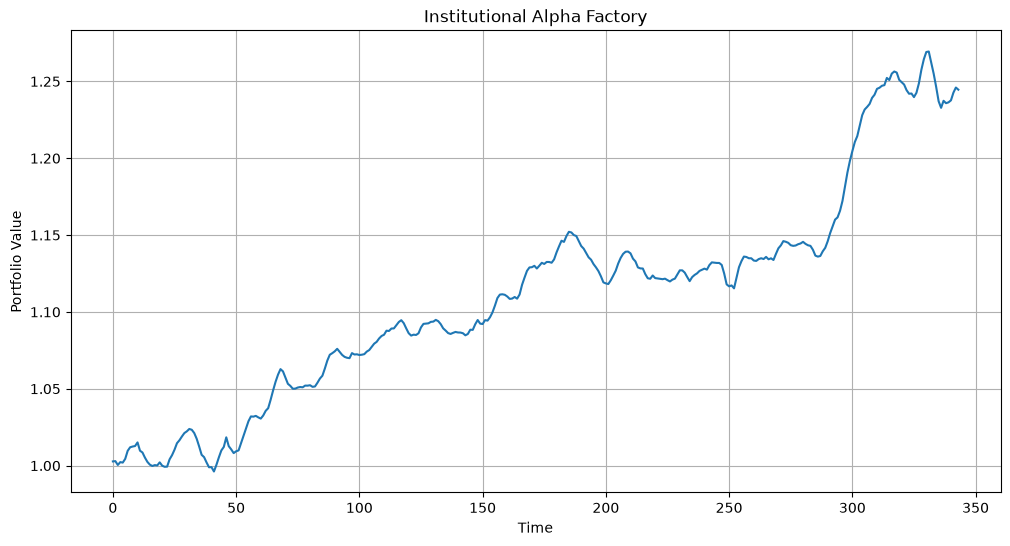

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

backtest = pd.read_csv("alpha_factory_backtest.csv")

plt.figure(figsize=(12,6))
plt.plot(backtest["equity_curve"])
plt.title("Institutional Alpha Factory")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

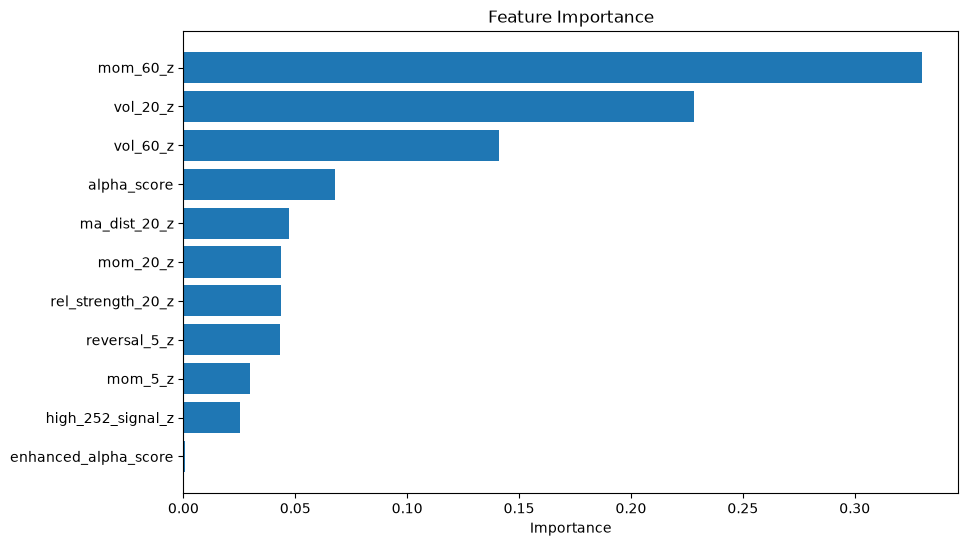

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

fi = pd.read_csv("alpha_factory_feature_importance.csv")

fi = fi.sort_values("Importance")

plt.figure(figsize=(10,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

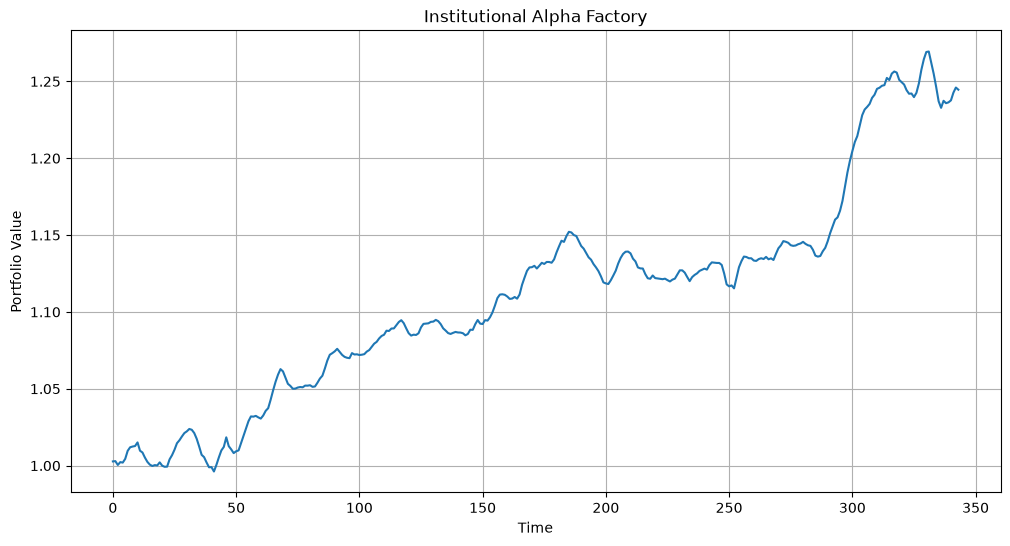

In [5]:
plt.figure(figsize=(12,6))
plt.plot(backtest["equity_curve"])
plt.title("Institutional Alpha Factory")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.savefig("equity_curve.png", bbox_inches="tight")
plt.show()